
# EDA notebook - report-aligned CNN/DailyMail analysis for SimpleNews

This notebook is the **authoritative EDA companion** for the final report.

It is designed to do two things clearly:

1. **Reproduce the report-facing EDA summary on the full test split** wherever possible.
2. Provide a **small set of useful, task-oriented exploratory analyses** that motivate the modeling choices in the report.

The emphasis is **not** on broad linguistic exploration. The emphasis is on the specific questions that matter for this project:

- How compressive is the task?
- How long are the articles and references?
- How dense are the articles in fact-critical items such as entities, numbers, and dates?
- Is **Lead-3** a meaningful baseline for this dataset?
- Why do we need **separate readability and faithfulness evaluation** rather than only ROUGE?



## How this notebook supports the report

This notebook is structured to align with the rubric emphasis on **good and useful EDA**, clear motivation, and reproducibility.

- The **full-test summary** is intended to support the dataset / EDA section of the report.
- The **plots** are chosen because they motivate actual design choices in the systems:
  - **length / compression** -> need explicit content selection, not only rewriting
  - **fact-item prevalence** -> need entity / number / date preservation
  - **lead bias** -> justifies including **Lead-3** as a strong baseline
  - **article vs. reference readability** -> supports evaluating readability separately from summary overlap

A deliberate distinction is made between:
- **authoritative full-test statistics** used to support the report, and
- **sampled exploratory analyses** used to motivate baselines without making the notebook unnecessarily slow.


In [1]:

from __future__ import annotations

import importlib.util
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR

for cand in [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]:
    if (cand / "src").exists():
        PROJECT_ROOT = cand
        break

def _ensure_flat_package(package_name: str, module_names: list[str], base_dir: Path) -> None:
    if package_name not in sys.modules:
        pkg = types.ModuleType(package_name)
        pkg.__path__ = [str(base_dir)]
        sys.modules[package_name] = pkg

    for module_name in module_names:
        full_name = f"{package_name}.{module_name}"
        if full_name in sys.modules:
            continue
        module_path = base_dir / f"{module_name}.py"
        if not module_path.exists():
            continue
        spec = importlib.util.spec_from_file_location(full_name, module_path)
        module = importlib.util.module_from_spec(spec)
        sys.modules[full_name] = module
        assert spec.loader is not None
        spec.loader.exec_module(module)

if (PROJECT_ROOT / "src").exists():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
else:
    # Fallback for flat-file delivery environments
    PROJECT_ROOT = NOTEBOOK_DIR
    _ensure_flat_package("src", ["preprocess", "evaluation", "io_utils"], NOTEBOOK_DIR)

from src.preprocess import (
    normalize_whitespace,
    tokenize,
    split_sentences,
    extract_entities,
    extract_numbers,
    extract_dates,
)
from src.evaluation import readability, rouge_n, rouge_l

try:
    from src.io_utils import load_csv, standardize_dataframe
except Exception:
    load_csv = None
    standardize_dataframe = None

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"

for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FORCE_RECOMPUTE = False
LEAD_BIAS_SAMPLE = 2000
SAVE_FIGURES = True



## Load the test split

The notebook prefers the following sources in order:

1. `data/test.csv` (best for raw-dataset EDA)
2. `outputs/system_runs/test_S0.csv`
3. `test_S0.csv`
4. `test_all_systems_combined.csv`
5. direct Hugging Face download as a last resort

This makes the notebook usable both in the full project folder and in a lighter artifact folder.


In [2]:

def _load_from_raw_test_csv(path: Path) -> tuple[pd.DataFrame, str] | None:
    if not path.exists():
        return None
    if load_csv is not None and standardize_dataframe is not None:
        raw, colmap = load_csv(path)
        df = standardize_dataframe(raw, colmap)
        return df[["doc_id", "title", "article", "reference"]].copy(), str(path)

    raw = pd.read_csv(path, low_memory=False)
    rename_map = {}
    if "highlights" in raw.columns and "reference" not in raw.columns:
        rename_map["highlights"] = "reference"
    raw = raw.rename(columns=rename_map)
    needed = [c for c in ["doc_id", "title", "article", "reference"] if c in raw.columns]
    if not {"article", "reference"}.issubset(raw.columns):
        return None
    out = raw[needed].copy()
    if "doc_id" not in out.columns:
        out["doc_id"] = range(len(out))
    if "title" not in out.columns:
        out["title"] = ""
    out["doc_id"] = out["doc_id"].astype(str)
    return out[["doc_id", "title", "article", "reference"]].reset_index(drop=True), str(path)

def _load_from_system_or_combined_csv(path: Path) -> tuple[pd.DataFrame, str] | None:
    if not path.exists():
        return None
    df = pd.read_csv(path, low_memory=False)
    if "system" in df.columns:
        if (df["system"].astype(str).str.upper() == "S0").any():
            df = df.loc[df["system"].astype(str).str.upper() == "S0"].copy()
        elif "doc_id" in df.columns:
            df = df.drop_duplicates(subset="doc_id").copy()

    if not {"article", "reference"}.issubset(df.columns):
        return None

    keep = [c for c in ["doc_id", "title", "article", "reference"] if c in df.columns]
    out = df[keep].copy()
    if "doc_id" not in out.columns:
        out["doc_id"] = range(len(out))
    if "title" not in out.columns:
        out["title"] = ""
    out["doc_id"] = out["doc_id"].astype(str)
    return out[["doc_id", "title", "article", "reference"]].reset_index(drop=True), str(path)

def load_test_dataframe() -> tuple[pd.DataFrame, str]:
    candidates = [
        PROJECT_ROOT / "data" / "test.csv",
        PROJECT_ROOT / "outputs" / "system_runs" / "test_S0.csv",
        PROJECT_ROOT / "test_S0.csv",
        NOTEBOOK_DIR / "test_S0.csv",
        PROJECT_ROOT / "test_all_systems_combined.csv",
        NOTEBOOK_DIR / "test_all_systems_combined.csv",
    ]

    for path in candidates:
        if path.name == "test.csv":
            loaded = _load_from_raw_test_csv(path)
        else:
            loaded = _load_from_system_or_combined_csv(path)
        if loaded is not None:
            return loaded

    try:
        from datasets import load_dataset
    except ImportError as e:
        raise FileNotFoundError(
            "Could not find a local test split and the `datasets` package is unavailable for fallback download."
        ) from e

    ds = load_dataset("cnn_dailymail", "3.0.0", split="test")
    raw = ds.to_pandas()
    out = pd.DataFrame()
    out["doc_id"] = np.arange(len(raw)).astype(str)
    out["title"] = raw["article"].fillna("").astype(str).str.split(".").str[0]
    out["article"] = raw["article"].fillna("").astype(str)
    out["reference"] = raw["highlights"].fillna("").astype(str)
    return out, "huggingface://cnn_dailymail/3.0.0/test"

test_df, test_source = load_test_dataframe()
display(Markdown(f"**Loaded source:** `{test_source}`"))
display(Markdown(f"**Number of test documents:** {len(test_df):,}"))
test_df.head(2)


**Loaded source:** `/mnt/data/test_S0.csv`

**Number of test documents:** 11,490

,doc_id,title,article,reference
0,0,NaN,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...
1,1,NaN,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b..."



## Full-test EDA features using the shared extraction pipeline

This section computes the document-level features used for the EDA summary.

Important note on interpretation:

- The **entity / number / date counts here are computed with the same shared extraction pipeline used later by the faithfulness metrics**.
- This is good for **methodological consistency**, but it also means the raw counts are **extractor-dependent**.
- In particular, the entity extractor is intentionally permissive because it is used as a faithfulness anchor. So the most useful signals are:
  - **presence / prevalence**
  - **relative density**
  - **task motivation**


In [3]:

eda_cache_path = CACHE_DIR / "test_eda_doc_features_same_pipeline.csv"
summary_path = TABLE_DIR / "test_eda_table_i_same_pipeline.csv"

LEGACY_EDA_RENAME = {
    "article_sents": "article_sentences",
    "reference_sents": "reference_sentences",
    "article_fre": "article_flesch",
    "reference_fre": "reference_flesch",
    "has_ent": "has_entity",
    "has_num": "has_number",
    "has_date": "has_date",
    "num_ent": "entity_count",
    "num_num": "number_count",
    "num_date": "date_count",
}

def compute_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in df.itertuples(index=False):
        article = normalize_whitespace(str(getattr(row, "article", "") or ""))
        reference = normalize_whitespace(str(getattr(row, "reference", "") or ""))

        article_tokens = tokenize(article)
        reference_tokens = tokenize(reference)
        article_read = readability(article)
        reference_read = readability(reference)

        ent_count = len(extract_entities(article))
        num_count = len(extract_numbers(article))
        date_count = len(extract_dates(article))

        rows.append({
            "doc_id": str(getattr(row, "doc_id", "")),
            "article_words": len(article_tokens),
            "reference_words": len(reference_tokens),
            "article_sentences": len(split_sentences(article)),
            "reference_sentences": len(split_sentences(reference)),
            "compression_ratio": (len(reference_tokens) / len(article_tokens)) if article_tokens else np.nan,
            "article_flesch": article_read["flesch_reading_ease"],
            "reference_flesch": reference_read["flesch_reading_ease"],
            "article_fkgl": article_read["fkgl"],
            "reference_fkgl": reference_read["fkgl"],
            "has_entity": ent_count > 0,
            "has_number": num_count > 0,
            "has_date": date_count > 0,
            "entity_count": ent_count,
            "number_count": num_count,
            "date_count": date_count,
        })
    return pd.DataFrame(rows)

if eda_cache_path.exists() and not FORCE_RECOMPUTE:
    eda_df = pd.read_csv(eda_cache_path)
    rename_map = {old: new for old, new in LEGACY_EDA_RENAME.items() if old in eda_df.columns}
    if rename_map:
        eda_df = eda_df.rename(columns=rename_map)
else:
    eda_df = compute_eda_features(test_df)
    eda_df.to_csv(eda_cache_path, index=False)

required_cols = {
    "article_words",
    "reference_words",
    "article_sentences",
    "reference_sentences",
    "compression_ratio",
    "article_flesch",
    "reference_flesch",
    "article_fkgl",
    "reference_fkgl",
    "has_entity",
    "has_number",
    "has_date",
    "entity_count",
    "number_count",
    "date_count",
}
missing_cols = sorted(required_cols - set(eda_df.columns))
if missing_cols:
    raise ValueError(f"EDA cache is missing required columns: {missing_cols}")

eda_df.head()


,article_words,reference_words,article_sentences,reference_sentences,compression_ratio,has_entity,has_number,has_date,entity_count,number_count,date_count,article_flesch,reference_flesch,article_fkgl,reference_fkgl
0,569,34,27,2,0.059754,True,True,True,46,5,2,35.710937,22.868235,13.476952,14.292941
1,408,42,19,2,0.102941,True,True,False,21,1,0,54.994276,70.705714,10.962617,8.614286
2,702,35,38,3,0.049858,True,True,True,52,16,10,51.450824,45.130476,10.593898,9.862857
3,203,42,11,3,0.206897,True,True,True,21,3,1,52.082048,46.460894,10.556967,10.174146
4,364,41,22,3,0.112637,True,True,False,21,2,0,56.168836,42.334065,9.535255,10.749756



## Table I-style compact summary for the full 11,490-document test split


In [4]:

table_i = pd.DataFrame({
    "Statistic": [
        "Average article length (words)",
        "Average reference length (words)",
        "Average article sentence count",
        "Average reference sentence count",
        "Mean word-level compression ratio",
        "Articles with at least one named entity",
        "Articles with at least one number",
        "Articles with at least one date expression",
        "Mean extracted entities per article",
        "Mean extracted numbers per article",
        "Mean extracted dates per article",
    ],
    "Value": [
        round(float(eda_df["article_words"].mean()), 1),
        round(float(eda_df["reference_words"].mean()), 1),
        round(float(eda_df["article_sentences"].mean()), 1),
        round(float(eda_df["reference_sentences"].mean()), 1),
        f"{eda_df['compression_ratio'].mean() * 100:.1f}%",
        f"{eda_df['has_entity'].mean() * 100:.1f}%",
        f"{eda_df['has_number'].mean() * 100:.1f}%",
        f"{eda_df['has_date'].mean() * 100:.1f}%",
        round(float(eda_df["entity_count"].mean()), 1),
        round(float(eda_df["number_count"].mean()), 1),
        round(float(eda_df["date_count"].mean()), 1),
    ],
})

table_i.to_csv(summary_path, index=False)
display(Markdown("**Authoritative EDA summary (same extractor as the faithfulness metrics):**"))
table_i


**Authoritative EDA summary (same extractor as the faithfulness metrics):**

,Statistic,Value
0,Average article length (words),680.2
1,Average reference length (words),51.7
2,Average article sentence count,32.5
3,Average reference sentence count,3.8
4,Mean word-level compression ratio,9.5%
5,Articles with at least one named entity,100.0%
6,Articles with at least one number,96.2%
7,Articles with at least one date expression,64.4%
8,Mean extracted entities per article,40.0
9,Mean extracted numbers per article,7.5



### Interpretation

The most important dataset-level takeaways from the full test split are:

- The task is **strongly compressive**: references are much shorter than articles.
- The articles are **fact-dense**, especially for entities and numbers.
- This directly motivates:
  - **explicit content selection**
  - **fact-aware constraints**
  - **separate readability and faithfulness evaluation**

If your report contains a compact EDA table, this is the cleanest place to source it from.


In [5]:

def save_and_show(fig, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

display(Markdown(f"Plots will be saved to: `{FIG_DIR}`"))


Plots will be saved to: `/mnt/data/outputs/figures`


## Plot 1 - Article length distribution

This is the cleanest length-distribution figure for the report or appendix.

It shows a clear **right-skewed** distribution: many articles are moderate in length, but there is a substantial long-tail of very long articles.  
That matters for modeling because full-article methods must cope with long inputs, while structured selectors can avoid rewriting unnecessary context.


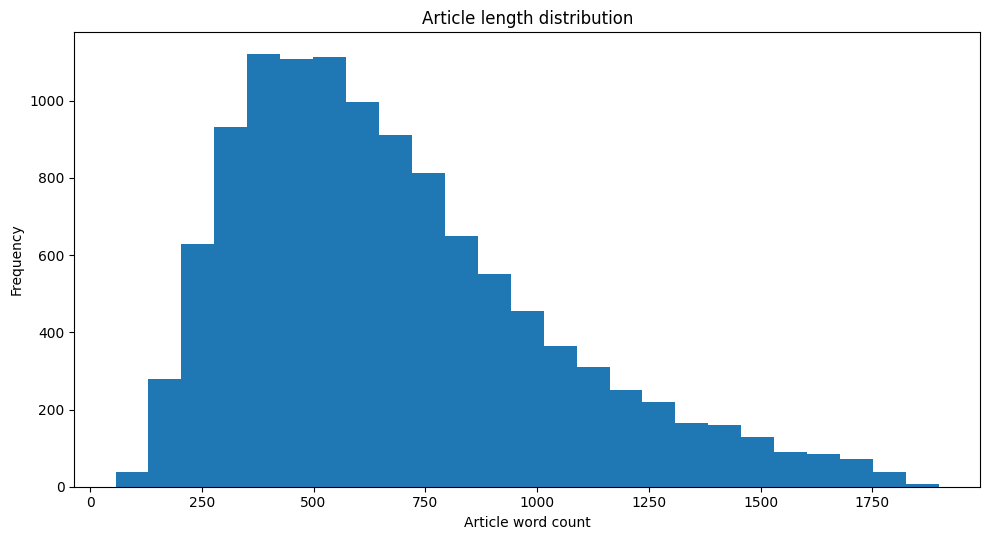

In [6]:

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(eda_df["article_words"].dropna(), bins=25)
ax.set_title("Article length distribution")
ax.set_xlabel("Article word count")
ax.set_ylabel("Frequency")
fig.tight_layout()
save_and_show(fig, "eda_article_length_distribution.png")



## Plot 2 - Fact-critical item prevalence

This plot is useful because it motivates why the project should explicitly protect factual items.

Even if the raw extractor counts are aggressive, the prevalence signal is clear:
- almost all articles contain **named entities**
- almost all contain **numbers**
- many contain **dates**

That is exactly why coverage-aware selection and fact-preserving evaluation are central to the project rather than optional extras.


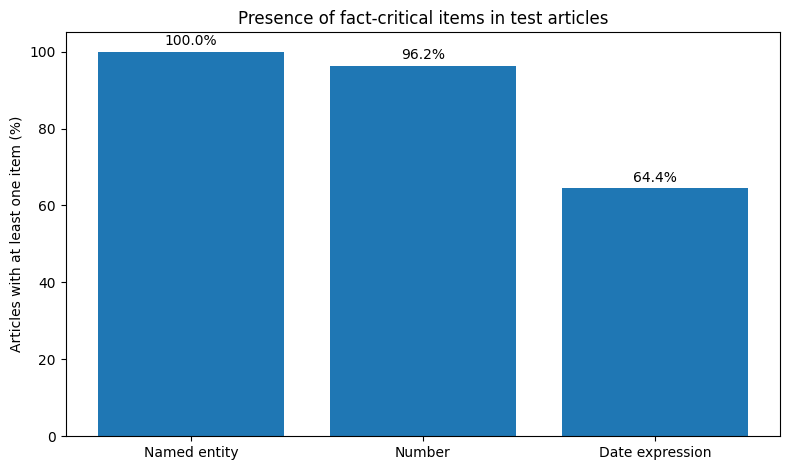

In [7]:

prevalence_df = pd.DataFrame({
    "category": ["Named entity", "Number", "Date expression"],
    "pct": [
        eda_df["has_entity"].mean() * 100,
        eda_df["has_number"].mean() * 100,
        eda_df["has_date"].mean() * 100,
    ],
})

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(prevalence_df["category"], prevalence_df["pct"])
ax.set_title("Presence of fact-critical items in test articles")
ax.set_ylabel("Articles with at least one item (%)")
ax.set_ylim(0, 105)
for x, y in zip(prevalence_df["category"], prevalence_df["pct"]):
    ax.text(x, y + 1.0, f"{y:.1f}%", ha="center", va="bottom", fontsize=10)
fig.tight_layout()
save_and_show(fig, "eda_fact_item_prevalence.png")



## Plot 3 - Article vs. reference readability

This plot helps keep the EDA honest.

The references are **much shorter** and are somewhat easier on average, but they are still **summary-style targets**, not controlled simplifications for adult ESL readers.  
So ROUGE against the highlights is useful for **content retention**, but it is **not enough by itself** to evaluate accessibility.


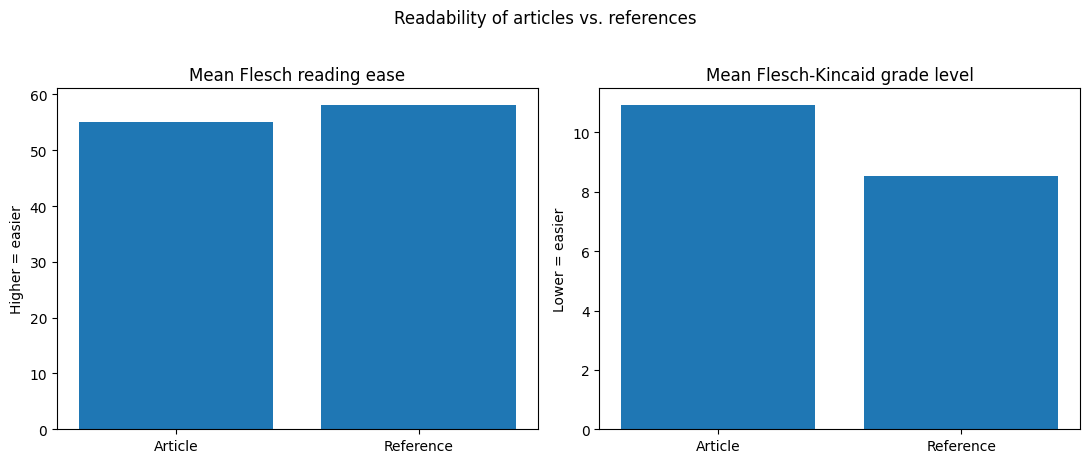

,text_type,Mean Flesch reading ease,Mean FKGL
0,Article,55.09,10.94
1,Reference,58.17,8.53


In [8]:

readability_summary = pd.DataFrame({
    "text_type": ["Article", "Reference"],
    "Mean Flesch reading ease": [
        eda_df["article_flesch"].mean(),
        eda_df["reference_flesch"].mean(),
    ],
    "Mean FKGL": [
        eda_df["article_fkgl"].mean(),
        eda_df["reference_fkgl"].mean(),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(readability_summary["text_type"], readability_summary["Mean Flesch reading ease"])
axes[0].set_title("Mean Flesch reading ease")
axes[0].set_ylabel("Higher = easier")

axes[1].bar(readability_summary["text_type"], readability_summary["Mean FKGL"])
axes[1].set_title("Mean Flesch-Kincaid grade level")
axes[1].set_ylabel("Lower = easier")

fig.suptitle("Readability of articles vs. references", y=1.02)
fig.tight_layout()
save_and_show(fig, "eda_readability_articles_vs_references.png")

readability_summary.round(2)



## Sampled exploratory analysis - lead bias snapshot

This section is intentionally **sampled** rather than full-test to keep the notebook responsive.

The goal is not to create a final benchmark result.  
The goal is to answer one EDA question:

> Are the first few sentences already a strong baseline for news-style content selection?

That is important because it motivates including **Lead-3** in the final system comparison.


In [9]:

lead_bias_cache_path = TABLE_DIR / "test_eda_lead_bias_sample.csv"

if lead_bias_cache_path.exists() and not FORCE_RECOMPUTE:
    lead_bias_df = pd.read_csv(lead_bias_cache_path)
else:
    lead_n = min(LEAD_BIAS_SAMPLE, len(test_df))
    rows = []
    for row in test_df.iloc[:lead_n].itertuples(index=False):
        article = normalize_whitespace(str(getattr(row, "article", "") or ""))
        reference = normalize_whitespace(str(getattr(row, "reference", "") or ""))
        sentences = split_sentences(article)
        for k in [1, 3, 5]:
            lead_text = " ".join(sentences[:k]).strip()
            rows.append({
                "k": k,
                "rouge1": rouge_n(lead_text, reference, 1),
                "rougel": rouge_l(lead_text, reference),
                "lead_words": len(tokenize(lead_text)),
            })
    lead_bias_df = pd.DataFrame(rows).groupby("k", as_index=False).mean(numeric_only=True)
    lead_bias_df.to_csv(lead_bias_cache_path, index=False)

lead_bias_df


,k,rouge1,rougel,words
0,1,0.253096,0.180053,24.2200
1,3,0.324027,0.216188,72.3635
2,5,0.294449,0.196900,111.4810


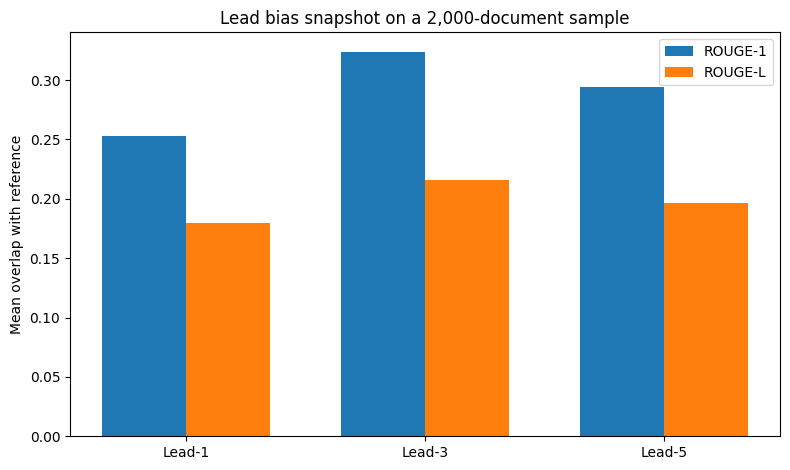

In [10]:

fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(lead_bias_df))
width = 0.35

ax.bar(x - width / 2, lead_bias_df["rouge1"], width, label="ROUGE-1")
ax.bar(x + width / 2, lead_bias_df["rougel"], width, label="ROUGE-L")

ax.set_xticks(x)
ax.set_xticklabels([f"Lead-{int(k)}" for k in lead_bias_df["k"]])
ax.set_ylabel("Mean overlap with reference")
ax.set_title(f"Lead bias snapshot on a {min(LEAD_BIAS_SAMPLE, len(test_df)):,}-document sample")
ax.legend()

fig.tight_layout()
save_and_show(fig, "eda_lead_bias_snapshot.png")



## EDA conclusions

These are the key takeaways this notebook supports:

1. **Compression is severe.**  
   The dataset is not just a rewriting task; it is a **selection + rewriting** task.

2. **Fact density is high.**  
   Because articles are packed with entities, numbers, and dates, generic salience ranking is not enough.

3. **Lead bias is real.**  
   The first few sentences already give a meaningful baseline, so **Lead-3** is worth keeping as a strong news prior.

4. **Readability must be evaluated separately from overlap.**  
   The reference highlights are shorter and somewhat easier, but they are still **summary-style supervision**, not dedicated simplifications.

5. **Methodological consistency matters.**  
   This notebook uses the same shared extraction pipeline as the later faithfulness metrics, so the EDA and evaluation are aligned.
